In [2]:
#Preamble
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math
import os

In [111]:
dir = r"..\TOPAS_data\do_field\Dose"
list = os.listdir(dir)

topas_dose = pd.DataFrame(columns=['Depth', 'Dose'])
for file in list:
    newrow = {}
    newrow['Depth'] = float(os.path.splitext(file)[0])
    newrow['Dose'] = pd.read_csv(os.path.join(dir,file), skiprows=5, header=None).iloc[0][0]

    newrow = pd.DataFrame([newrow])
    topas_dose = pd.concat([topas_dose, newrow], ignore_index=True)

#normalise dose
topas_dose['Dose_norm'] = topas_dose['Dose']/max(topas_dose['Dose'])

C:\Users\linux\AppData\Local\Temp\ipykernel_2924\2766935298.py:11: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  topas_dose = pd.concat([topas_dose, newrow], ignore_index=True)


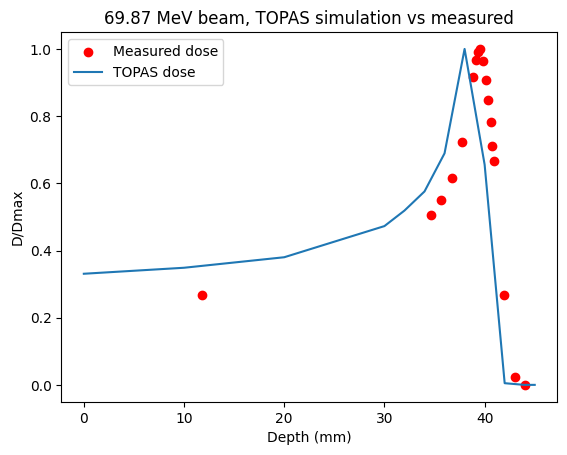

In [112]:
data = pd.read_excel(r"../Mid LET calculation/BP 69.87 measured - copy for scripts.xlsx")

BP_measured = pd.DataFrame()
BP_measured['Depth'] = data['Depth (mm)']
BP_measured['Dose'] = data['Dose (Gy)']/np.max(data['Dose (Gy)'])

plt.scatter(BP_measured['Depth'], BP_measured['Dose'], label='Measured dose', color='r')
plt.plot(topas_dose['Depth'], topas_dose['Dose_norm'], label = 'TOPAS dose')
plt.title('69.87 MeV beam, TOPAS simulation vs measured')
plt.xlabel('Depth (mm)')
plt.ylabel('D/Dmax')
plt.legend()

In [117]:
dir = r"..\TOPAS_data\do_field\LET"
list = os.listdir(dir)

topas_let = pd.DataFrame(columns=['Depth', 'LET'])
for file in list:
    newrow = {}
    newrow['Depth'] = float(os.path.splitext(file)[0])
    newrow['LET'] = pd.read_csv(os.path.join(dir,file), skiprows=5, header=None).iloc[0][0]

    if newrow['LET'] !='# The value of the combined scorer for those voxels/bins has been set to 0.':
        newrow = pd.DataFrame([newrow])
        topas_let = pd.concat([topas_let, newrow], ignore_index=True)

topas_let['LET'] = topas_let['LET']/10

print(topas_let)

   Depth       LET
0    0.0  0.461090
1   10.0  1.009273
2   20.0  0.944586
3   30.0  0.819899
4   32.0  0.772967
5   34.0  0.777052
6   36.0  0.775179
7   38.0  0.833931
8   40.0  1.107815
9   42.0  0.966800


C:\Users\linux\AppData\Local\Temp\ipykernel_2924\2296686164.py:12: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  topas_let = pd.concat([topas_let, newrow], ignore_index=True)


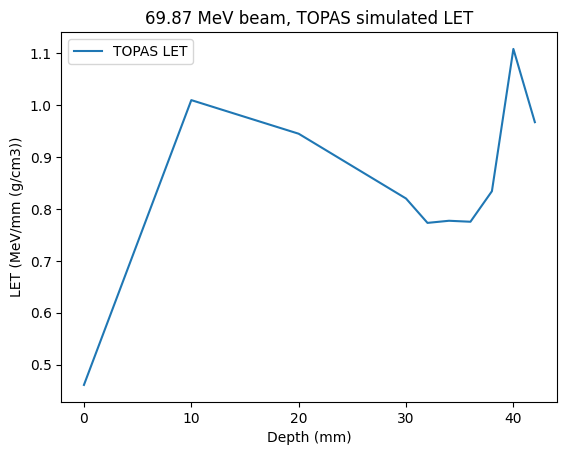

In [118]:
plt.plot(topas_let['Depth'], topas_let['LET'], label = 'TOPAS LET')
plt.title('69.87 MeV beam, TOPAS simulated LET')
plt.xlabel('Depth (mm)')
plt.ylabel('LET (MeV/mm (g/cm3))')
plt.legend()

# Getting NIST data

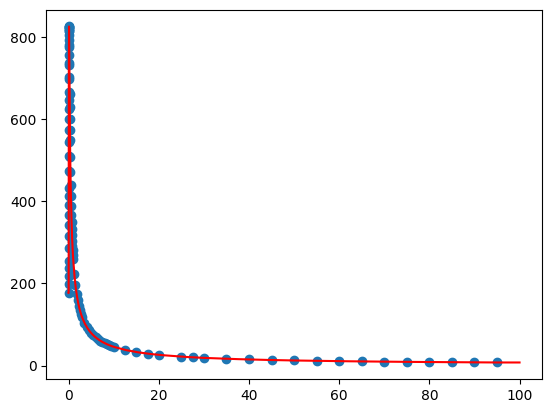

In [54]:
#Load in NIST SP data for protons
data = pd.read_csv(r"C:\Users\linux\Downloads\NIST stopping power.csv", sep='|',header=None)

SPdata = pd.DataFrame(columns=['Energy', 'SP'])
SPdata['Energy'] = data.iloc[:,0]
SPdata['SP'] = data.iloc[:,1]
SPdata = SPdata[SPdata['Energy']<100]

#interpolate data down to 4 digits
Expanded_SP = pd.DataFrame(columns=['Energy', 'SP'])
Expanded_SP['Energy'] = np.arange(0, 100, 0.0001)
Expanded_SP['SP'] = np.interp(Expanded_SP['Energy'], SPdata['Energy'], SPdata['SP'])

plt.scatter(SPdata['Energy'], SPdata['SP'], label='NIST data')
plt.plot(Expanded_SP['Energy'], Expanded_SP['SP'], label='Interpolation', color='r')

# Reading in each particle phsp to calculate LET

In [131]:
def Calculate_LET_from_phsp(phsp_path, NIST_data):
    #Read in phsp file
    d = pd.read_csv(phsp_path, header=None, sep='\s+')
    #Select only protons
    d = d.loc[d.iloc[:,7]==2212]
    d.reset_index(inplace=True)

    particle_data = pd.DataFrame(columns=['Energy', 'LET'])
    particle_data['Energy'] = d.iloc[:,6]

    #Look up stopping power for each kinetic energy
    for i in range(len(particle_data)):
        en = particle_data.loc[i, 'Energy']

        sp = Expanded_SP[round(NIST_data['Energy'],4)==round(en,4)]
        
        #convert to LET
        particle_data.loc[i, 'LET'] = np.array(sp['SP']/10)[0]

    mean_LET = round(particle_data['LET'].mean(),2)
    median_LET = round(particle_data['LET'].median(),2)

    return mean_LET, median_LET

<>:3: SyntaxWarning: invalid escape sequence '\s'
<>:3: SyntaxWarning: invalid escape sequence '\s'
C:\Users\linux\AppData\Local\Temp\ipykernel_2924\2811266463.py:3: SyntaxWarning: invalid escape sequence '\s'
  d = pd.read_csv(phsp_path, header=None, sep='\s+')


C:\Users\linux\AppData\Local\Temp\ipykernel_2924\2370196543.py:11: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  topas_let = pd.concat([topas_let, newrow], ignore_index=True)


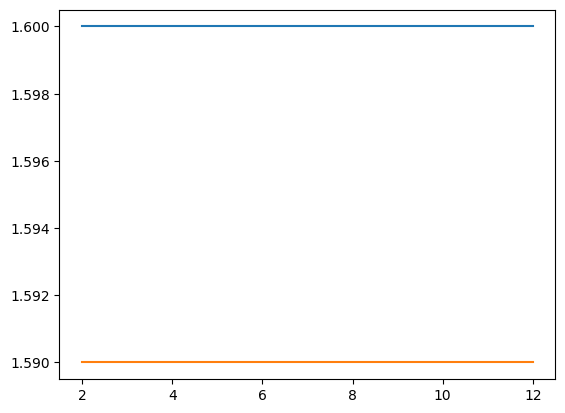

In [133]:
dir = r"C:\Users\linux\Downloads\Trial_phases"
list = os.listdir(dir)

topas_let = pd.DataFrame(columns=['Depth', 'Mean LET', 'Median LET'])
for file in list:
    newrow = {}
    newrow['Depth'] = float(os.path.splitext(file)[0])
    newrow['Mean LET'], newrow['Median LET'] = Calculate_LET_from_phsp(os.path.join(dir,file), Expanded_SP)

    newrow = pd.DataFrame([newrow])
    topas_let = pd.concat([topas_let, newrow], ignore_index=True)

plt.plot(topas_let['Depth'], topas_let['Mean LET'])
plt.plot(topas_let['Depth'], topas_let['Median LET'])